In [2]:
%pip install matplotlib seaborn pandas

  Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl (8.2 MB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl (2.3 MB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl (7.1 MB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


dataset_path = "../data/final_dataset.csv"

if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
    print("✅ Dataset chargé avec succès !")
    print(f"Nombre de lignes : {len(df)}")
    display(df.head())
else:
    print("❌ Erreur : Le fichier n'est pas au bon endroit.")

✅ Dataset chargé avec succès !
Nombre de lignes : 82486


,text,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


C:\Users\damie\AppData\Local\Temp\ipykernel_12184\3990736051.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


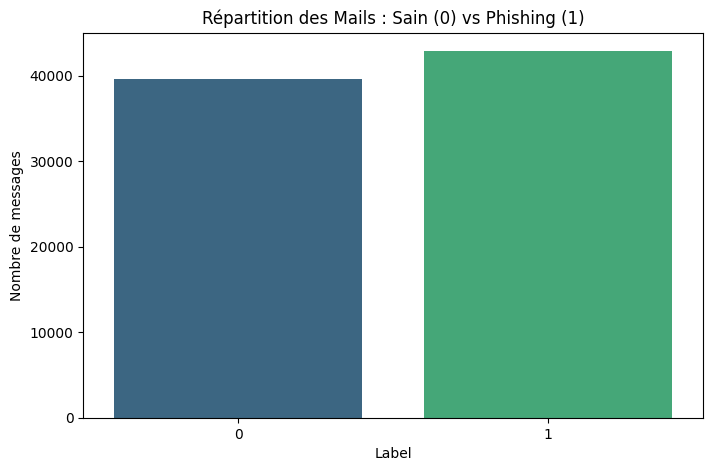

label
1    51.997915
0    48.002085
Name: proportion, dtype: float64


In [2]:
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title("Répartition des Mails : Sain (0) vs Phishing (1)")
plt.xlabel("Label")
plt.ylabel("Nombre de messages")
plt.show()


print(df['label'].value_counts(normalize=True) * 100)

c:\Users\damie\Desktop\projet_cyber_ai\CyberXAI_Anti-Spam-Phishing\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


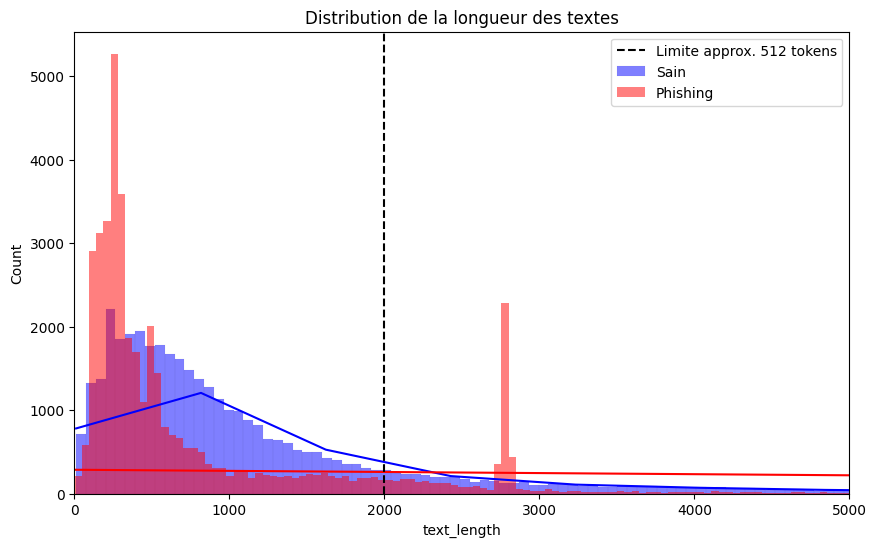

In [3]:
# Calcul de la longueur en caractères
df['text_length'] = df['text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10, 6))
sns.histplot(df[df['label'] == 0]['text_length'], label='Sain', color='blue', kde=True)
sns.histplot(df[df['label'] == 1]['text_length'], label='Phishing', color='red', kde=True)
plt.axvline(x=2000, color='black', linestyle='--', label='Limite approx. 512 tokens')
plt.title("Distribution de la longueur des textes")
plt.legend()
plt.xlim(0, 5000) 
plt.show()